In [1]:

from sklearn.metrics import roc_auc_score
import pandas as pd
import pickle as pkl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import io, os
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, multilabel_confusion_matrix

In [2]:
def calc_metrics(y_true, pred):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=np.array([0,1])).ravel()
    
    return pd.DataFrame({'acc': accuracy_score(y_true, pred),
                         'f1': f1_score(y_true, pred),
                         'tn': tn,
                         'fp': fp,
                         'fn': fn,
                         'tp': tp}, index=np.array([0]))

In [3]:

old_data_dir = '/media/ssd1/huong/PCR-huong/data/'
new_data_dir = os.path.join(old_data_dir,'new_data')

In [4]:
groundtruth_df = pd.read_csv(os.path.join(old_data_dir, 'groundtruth_df_target_data_split_v2.csv'))
retest_df = pd.read_csv(os.path.join(old_data_dir, 'retest_df_target_data.csv'))
karlen_df = pd.read_csv(os.path.join(old_data_dir, 'karlen_target_data.csv'))
chip60_df = pd.read_csv(os.path.join(old_data_dir, 'chip60_target_data.csv'))
known_df = pd.read_csv(os.path.join(old_data_dir, 'known_dilution_data.csv'))


In [5]:
curve_df = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='curve_data')
sample_info = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='igi_gene_call')

join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))

# # new data
# join_df = pd.read_pickle(os.path.join(new_data_dir, 'new_join_df_1.pkl'))

thermo_sample_ids = join_df[join_df.target == 'MS2'].sample_id.unique()
join_df['test_kit'] = 'LuNER'
join_df.loc[join_df.sample_id.isin(thermo_sample_ids),'test_kit'] = 'Thermo'


In [6]:
### test data
# test_pred = pd.read_csv(os.path.join(new_data_dir,'model_outputs', '3_29_curve_resampling_test.csv'))
test_pred = pd.read_csv(os.path.join(old_data_dir, 'model_outputs','experimental', 'seq_test_pred_df.csv'))

print(test_pred.shape)
test_pred = (test_pred
             .merge(groundtruth_df[['sample_id','curve_idx','sample_type','target','groundtruth_target','igi_call']],
                    on='curve_idx'))
test_pred['encoded_igi_call'] = 1*(test_pred.igi_call == 'Positive')
print(test_pred.shape)

(6175, 3)
(6175, 9)


In [13]:
# new_groundtruth = pd.read_csv(os.path.join(new_data_dir, 'new_groundtruth_df_target_data_v1.csv'))
# common_sample_id = groundtruth_df[groundtruth_df.sample_id.isin(new_groundtruth[(new_groundtruth.sample_type == 'Negative Control (qPCR)') & (new_groundtruth.split == 'test')].sample_id.unique())].sample_id.unique()
# np.random.seed(3)
# water_well_ids = np.random.choice(common_sample_id, 24, replace=False)
# water_well_ids

array(['S252467', 'S849241', 'S596540', 'S1122921', 'S129321', 'S848971',
       'S1204874', 'S182691', 'S543840', 'S1272616', 'S942165', 'S893428',
       'S1210676', 'S543747', 'S1123116', 'S1098755', 'S849259',
       'S1122885', 'S1036641', 'S1193352', 'S1033346', 'S296630',
       'S849088', 'S1262657'], dtype=object)

In [14]:
np.random.seed(3)
water_well_ids = ['S252467', 'S849241', 'S596540', 'S1122921', 'S129321', 'S848971',
                  'S1204874', 'S182691', 'S543840', 'S1272616', 'S942165', 'S893428',
                  'S1210676', 'S543747', 'S1123116', 'S1098755', 'S849259', 'S1122885',
                  'S1036641', 'S1193352', 'S1033346', 'S296630', 'S849088', 'S1262657']
#np.random.choice(test_pred[test_pred.sample_type == 'Negative Control (qPCR)'].sample_id.unique(), 24, replace=False)

water_output_df = (test_pred.loc[test_pred.sample_id.isin(water_well_ids),
                                ['curve_idx','groundtruth_label','outputs','target','encoded_igi_call']]
                   .reset_index())
water_output_df['dilution_level'] = 0

water_output_df = (water_output_df[['curve_idx', 'groundtruth_label', 'outputs', 'dilution_level',
                                   'target', 'encoded_igi_call']]
                   .rename(columns={'encoded_igi_call':'new_igi_call',
                                    'groundtruth_label':'groundtruth_target'}))

In [7]:
igi_test_auc = roc_auc_score(test_pred.groundtruth_target, test_pred.encoded_igi_call)
print('IGI AUC on test:', igi_test_auc)
igi_test_fpr, igi_test_tpr, igi_test_thresholds = roc_curve(test_pred.groundtruth_target, test_pred.encoded_igi_call)
print('IGI values')
calc_metrics(test_pred.groundtruth_target, test_pred.encoded_igi_call)

IGI AUC on test: 0.9773955331412103
IGI values


,acc,f1,tn,fp,fn,tp
0,0.959352,0.976873,623,0,251,5301


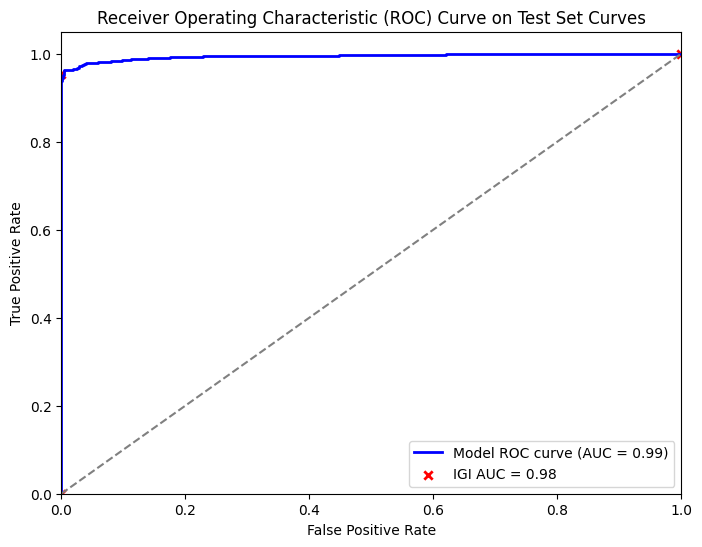

In [82]:
test_auc = roc_auc_score(test_pred.groundtruth_target, test_pred.outputs)
test_fpr, test_tpr, test_thresholds = roc_curve(test_pred.groundtruth_target, test_pred.outputs)

plt.figure(figsize=(8, 6))
plt.plot(test_fpr, test_tpr, color='blue', lw=2, label='Model ROC curve (AUC = {:.2f})'.format(test_auc))

plt.scatter(igi_test_fpr, igi_test_tpr, color = 'red', marker = 'x', linewidths=2, label='IGI AUC = {:.2f}'.format(igi_test_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Test Set Curves')
plt.legend(loc='lower right')
plt.show()


In [11]:
df = test_pred.copy()
test_acc = []
for thres in test_thresholds:
    df['pred'] = df.outputs >= thres
    
    metric_df = calc_metrics(df.groundtruth_target, df.pred)
    
    test_acc.append(metric_df.loc[0,'acc'])


In [12]:
print('Best test accuracy:', max(test_acc))
best_test_acc_thres = test_thresholds[np.array(test_acc).argmax()]


Best test accuracy: 0.977165991902834


In [13]:
test_pred['pred'] = 1*(test_pred.outputs >= best_test_acc_thres)
calc_metrics(test_pred.groundtruth_target, test_pred.pred)

,acc,f1,tn,fp,fn,tp
0,0.977166,0.987301,553,70,71,5481


In [22]:
### retest
# retest_pred = pd.read_csv(os.path.join(new_data_dir, 'model_outputs', '3_29_curve_resampling_retest.csv'))
retest_pred = pd.read_csv(os.path.join(old_data_dir, 'model_outputs', 'experimental', 'seq_retest_pred_df.csv'))

print(retest_pred.shape)
retest_pred = (retest_pred
               .merge(retest_df.loc[(~retest_df.target.isin(['RnaseP','MS2'])) &
                                    ~(retest_df.final_patient_result.isna()) & 
                                    (retest_df.final_patient_result != 'ReSample'),
                                    ['curve_idx','target','groundtruth_target','igi_call']],
                      on='curve_idx'))
retest_pred['encoded_igi_call'] = 1*(retest_pred.igi_call == 'Positive')
print(retest_df.shape)
print(retest_pred.shape)

(4084, 3)
(4084, 31)
(2749, 7)


In [23]:
print('IGI on retest')

igi_retest_auc = roc_auc_score(retest_pred.groundtruth_target, retest_pred.encoded_igi_call)
print('IGI AUC on retest:', igi_retest_auc)
igi_retest_fpr, igi_retest_tpr, igi_retest_thresholds = roc_curve(retest_pred.groundtruth_target, retest_pred.encoded_igi_call)

calc_metrics(retest_pred.groundtruth_target, retest_pred.encoded_igi_call)

IGI on retest
IGI AUC on retest: 0.6842498802472164


,acc,f1,tn,fp,fn,tp
0,0.809749,0.358282,2080,392,131,146


Model AUC on retest: 0.7506104471160024


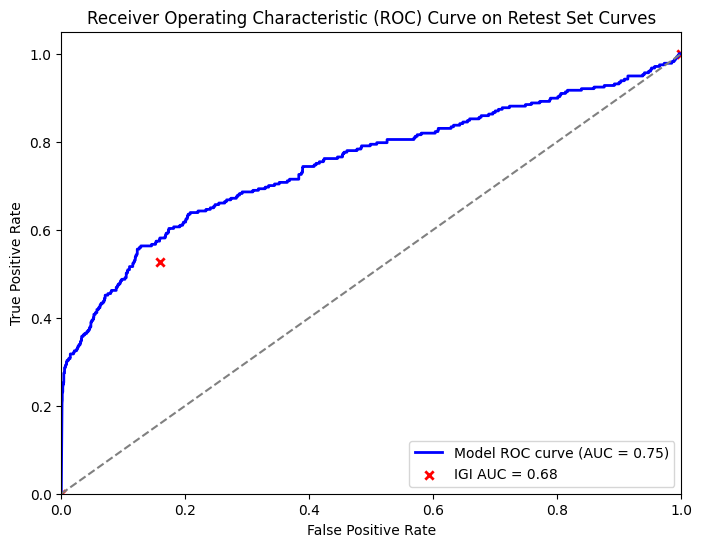

In [24]:
retest_auc = roc_auc_score(retest_pred.groundtruth_target, retest_pred.outputs)
print('Model AUC on retest:', retest_auc)
retest_fpr, retest_tpr, retest_thresholds = roc_curve(retest_pred.groundtruth_target, retest_pred.outputs)

plt.figure(figsize=(8, 6))
plt.plot(retest_fpr, retest_tpr, color='blue', lw=2, label='Model ROC curve (AUC = {:.2f})'.format(retest_auc))

plt.scatter(igi_retest_fpr, igi_retest_tpr, color = 'red', marker = 'x', linewidths=2, label='IGI AUC = {:.2f}'.format(igi_retest_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Retest Set Curves')
plt.legend(loc='lower right')
plt.show()


In [25]:
print('Model on Retest AUC:', retest_auc)
retest_pred['pred'] = 1*(retest_pred.outputs >= best_test_acc_thres)
calc_metrics(retest_pred.groundtruth_target, retest_pred.pred)

Model on Retest AUC: 0.7506104471160024


,acc,f1,tn,fp,fn,tp
0,0.763187,0.353525,1920,552,99,178


In [74]:
## known df
# known_pred = pd.read_csv(os.path.join(new_data_dir, 'model_outputs','3_29_curve_resampling_known.csv'))
known_pred = pd.read_csv(os.path.join(old_data_dir, 'model_outputs','experimental', 'seq_known_pred_df.csv'))


In [75]:
boxplot_known_df = known_df.copy()
boxplot_known_df = boxplot_known_df[boxplot_known_df.target != 'RnaseP']
boxplot_known_df['temp'] = boxplot_known_df.drn >= boxplot_known_df.threshold
boxplot_known_df['new_igi_call'] = 0
known_thres_df = boxplot_known_df[boxplot_known_df.temp == 1].groupby('curve_idx').cycle_no.min().reset_index()
for idx in boxplot_known_df.curve_idx.unique():
    if boxplot_known_df[boxplot_known_df.curve_idx == idx].target.unique() == 'RnaseP':
        boxplot_known_df.loc[boxplot_known_df.curve_idx == idx, 'new_igi_call'] = 1*(known_thres_df[known_thres_df.curve_idx == idx].cycle_no.mean() < 35)
    else:
        boxplot_known_df.loc[boxplot_known_df.curve_idx == idx, 'new_igi_call'] = 1*(known_thres_df[known_thres_df.curve_idx == idx].cycle_no.mean() < 40)


In [76]:

print(known_pred.shape)
known_pred = (known_pred
              .merge(boxplot_known_df.loc[boxplot_known_df.cycle_no == 1,
                                          ['curve_idx','dilution_level','target','new_igi_call']], 
                     on ='curve_idx')
              .rename(columns={'groundtruth_label':'groundtruth_target'})
              .reset_index(drop=True))

print(known_pred.shape)

(288, 3)
(192, 6)


In [85]:
print('IGI on known')
known_water_pred = pd.concat([water_output_df, known_pred], axis=0)
igi_known_auc = roc_auc_score(known_water_pred.groundtruth_target, known_water_pred.new_igi_call)
print('IGI AUC on known:', igi_known_auc)
igi_known_fpr, igi_known_tpr, igi_known_thresholds = roc_curve(known_water_pred.groundtruth_target, known_water_pred.new_igi_call)

calc_metrics(known_water_pred.groundtruth_target, known_water_pred.new_igi_call)

IGI on known
IGI AUC on known: 0.9921875


,acc,f1,tn,fp,fn,tp
0,0.985782,0.992126,19,0,3,189


Model AUC on known: 0.9887609649122807


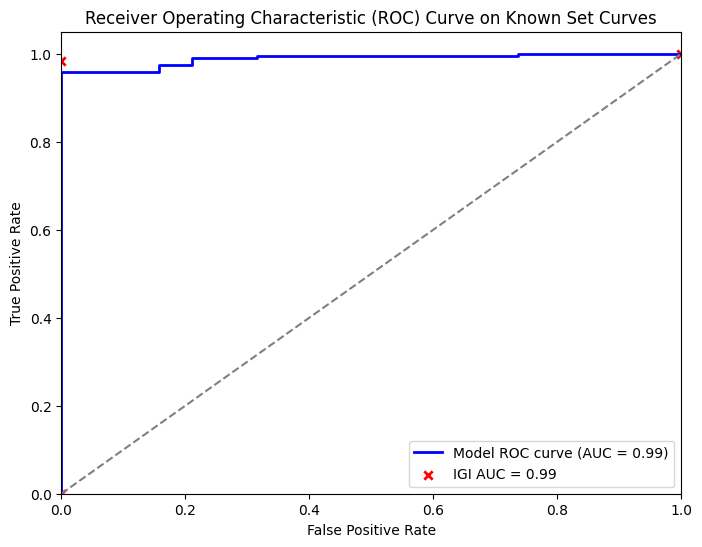

In [87]:
known_auc = roc_auc_score(known_water_pred.groundtruth_target, known_water_pred.outputs)
print('Model AUC on known:', known_auc)
known_fpr, known_tpr, known_thresholds = roc_curve(known_water_pred.groundtruth_target, known_water_pred.outputs)

plt.figure(figsize=(8, 6))
plt.plot(known_fpr, known_tpr, color='blue', lw=2, label='Model ROC curve (AUC = {:.2f})'.format(known_auc))

plt.scatter(igi_known_fpr, igi_known_tpr, color = 'red', marker = 'x', linewidths=2, label='IGI AUC = {:.2f}'.format(igi_known_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Known Set Curves')
plt.legend(loc='lower right')
plt.show()


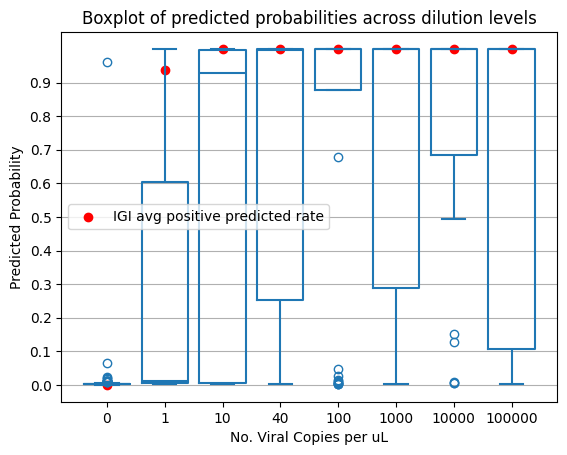

In [ ]:
boxplot_df = pd.concat([known_pred[['dilution_level','outputs']], water_output_df[['dilution_level','outputs']]], axis=0)

sns.boxplot(data=boxplot_df, x='dilution_level', y = 'outputs', fill = False)
plt.scatter(0, water_df.groupby('curve_idx').encoded_igi_call.mean().mean(), color = 'red', label = 'IGI avg positive predicted rate')
plt.scatter(1, boxplot_known_df[boxplot_known_df.dilution_level == 1].new_igi_call.mean(), color = 'red')
plt.scatter(2, boxplot_known_df[boxplot_known_df.dilution_level == 10].new_igi_call.mean(), color = 'red')
plt.scatter(3, boxplot_known_df[boxplot_known_df.dilution_level == 40].new_igi_call.mean(), color = 'red')
plt.scatter(4, boxplot_known_df[boxplot_known_df.dilution_level == 100].new_igi_call.mean(), color = 'red')
plt.scatter(5, boxplot_known_df[boxplot_known_df.dilution_level == 1000].new_igi_call.mean(), color = 'red')
plt.scatter(6, boxplot_known_df[boxplot_known_df.dilution_level == 10000].new_igi_call.mean(), color = 'red')
plt.scatter(7, boxplot_known_df[boxplot_known_df.dilution_level == 100000].new_igi_call.mean(), color = 'red')

plt.title('Boxplot of predicted probabilities across dilution levels')
plt.yticks(np.arange(0,1,0.1))
plt.xlabel('No. Viral Copies per uL')
plt.ylabel('Predicted Probability')
plt.grid(axis='y')
plt.legend()

In [47]:
with open('/media/ssd1/huong/PCR-huong/data/groundtruth_df_curve_dict.pkl','rb') as f:
    d = pkl.load(f)
    


In [49]:
d.keys()

dict_keys([24879, 24111, 24495, 25017, 24249, 24633, 25041, 24273, 24657, 25088, 24320, 24704, 70879, 71263, 27759, 28143, 27782, 28166, 27801, 28185, 27831, 28215, 67423, 67807, 67568, 67952, 61807, 62191, 114751, 115135, 114752, 115136, 60319, 60703, 60320, 60704, 11380, 11764, 11565, 11949, 103183, 103567, 103232, 103616, 55858, 56242, 55894, 56278, 64015, 64399, 117966, 118350, 118207, 118591, 3721, 4105, 3823, 4207, 59405, 59789, 59408, 59792, 9543, 9151, 9347, 21183, 20791, 20987, 3107, 2339, 2723, 3168, 2400, 2784, 3191, 2423, 2807, 3226, 2458, 2842, 8722, 8330, 8526, 8858, 8466, 8662, 35520, 35128, 35324, 35582, 35190, 35386, 48895, 49279, 48957, 49341, 49088, 49472, 49111, 49495, 51391, 51775, 120463, 120847, 120512, 120896, 108847, 109231, 108992, 109376, 109063, 109447, 93967, 94351, 4704, 5088, 4927, 5311, 4969, 5353, 91560, 91944, 91712, 92096, 125119, 125503, 106639, 107023, 106663, 107047, 106736, 107120, 18369, 18753, 18479, 18863, 18503, 18887, 18504, 18888, 53695, 540

In [ ]:
groundtruth = 